# Bayesian Machine Learning & Probabilistic Programming

Bayesian ML treats model parameters as **random variables** with probability distributions rather than fixed unknowns. This gives you uncertainty estimates, principled regularization, and the ability to incorporate prior knowledge — all things that point-estimate methods cannot provide.

**Why it matters for production ML:**
- Know *how confident* the model is, not just *what* it predicts
- Safely update beliefs as new data arrives (online Bayesian updating)
- Regularization falls out naturally from priors (L2 ↔ Gaussian prior, L1 ↔ Laplace prior)
- Small-data regime: priors prevent overfitting where MLE fails

**Contents:**
1. Bayes Theorem for ML
2. Conjugate Priors (closed-form posteriors)
3. Metropolis-Hastings MCMC from Scratch
4. Gaussian Processes from Scratch
5. PyMC: Bayesian Linear & Logistic Regression
6. Hierarchical Models (Partial Pooling)
7. Bayesian A/B Testing vs Frequentist p-values

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import scipy.stats as stats
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)
plt.rcParams['figure.dpi'] = 100
print('Libraries loaded')

Libraries loaded


## 1. Bayes Theorem for Machine Learning

The fundamental equation:

$$P(\theta | \mathcal{D}) = \frac{P(\mathcal{D} | \theta) \cdot P(\theta)}{P(\mathcal{D})}$$

where:
- $P(\theta)$ = **prior**: our belief about parameters *before* seeing data
- $P(\mathcal{D}|\theta)$ = **likelihood**: how probable the data is given the parameters
- $P(\mathcal{D})$ = **marginal likelihood** (evidence): normalising constant $= \int P(\mathcal{D}|\theta)P(\theta)d\theta$
- $P(\theta|\mathcal{D})$ = **posterior**: updated belief *after* seeing data

The **posterior predictive distribution** for a new point $x^*$:
$$P(y^* | x^*, \mathcal{D}) = \int P(y^* | x^*, \theta) \cdot P(\theta | \mathcal{D}) \, d\theta$$

This integrates over *all possible parameters weighted by their posterior probability* — giving calibrated uncertainty.

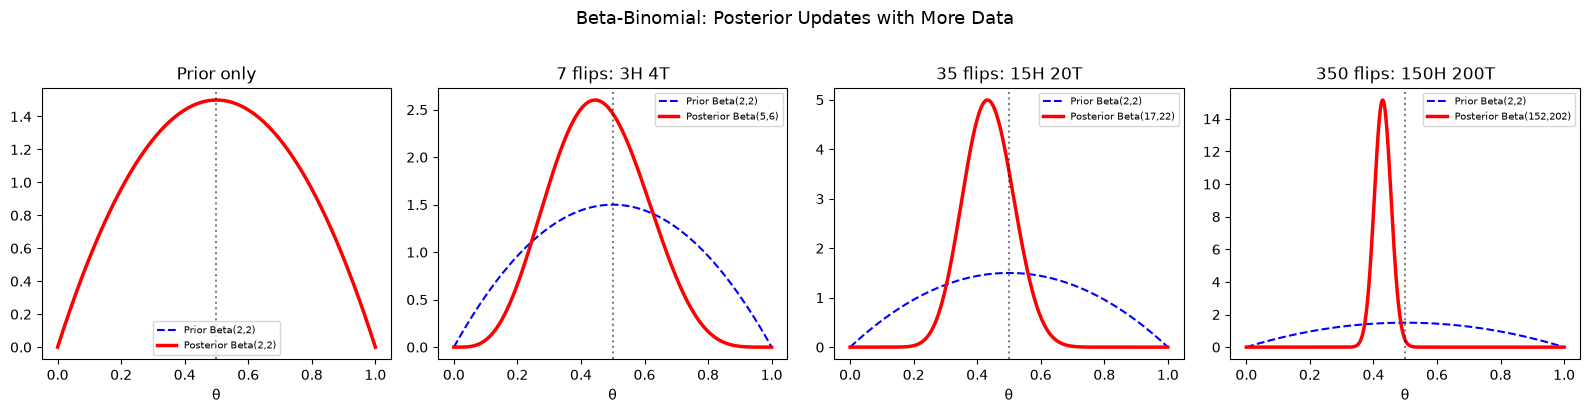

Key insight: posterior narrows (less uncertainty) as more data arrives


In [2]:
# --- Visualise how posterior updates with more data ---
# Beta-Binomial model: coin flip, θ = P(heads)
# Prior: θ ~ Beta(α, β)
# Likelihood: k heads in n flips ~ Binomial(n, θ)
# Posterior: θ|data ~ Beta(α + k, β + n - k)  ← conjugate!

theta = np.linspace(0, 1, 500)
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

alpha_prior, beta_prior = 2, 2  # weak prior: slightly prefer fair coin
datasets = [(0, 0, 'Prior only'), (3, 7, '7 flips: 3H 4T'), (15, 35, '35 flips: 15H 20T'), (150, 350, '350 flips: 150H 200T')]

for ax, (heads, total, title) in zip(axes, datasets):
    tails = total - heads
    a_post = alpha_prior + heads
    b_post = beta_prior + tails
    prior_pdf = stats.beta.pdf(theta, alpha_prior, beta_prior)
    post_pdf  = stats.beta.pdf(theta, a_post, b_post)
    ax.plot(theta, prior_pdf,  'b--', lw=1.5, label=f'Prior Beta({alpha_prior},{beta_prior})')
    ax.plot(theta, post_pdf,   'r-',  lw=2.5, label=f'Posterior Beta({a_post},{b_post})')
    ax.axvline(0.5, color='k', linestyle=':', alpha=0.5)
    ax.set_title(title); ax.set_xlabel('θ'); ax.legend(fontsize=7)

plt.suptitle('Beta-Binomial: Posterior Updates with More Data', y=1.02, fontsize=13)
plt.tight_layout(); plt.show()
print('Key insight: posterior narrows (less uncertainty) as more data arrives')

## 2. Conjugate Priors — Closed-Form Posteriors

A prior is **conjugate** to a likelihood if the posterior is in the same family as the prior. Computationally free — no sampling needed.

| Model | Prior | Posterior |
|-------|-------|-----------|
| Binomial likelihood | $\theta \sim \text{Beta}(\alpha, \beta)$ | $\theta|k,n \sim \text{Beta}(\alpha+k,\ \beta+n-k)$ |
| Gaussian (known $\sigma^2$) | $\mu \sim \mathcal{N}(\mu_0, \sigma_0^2)$ | $\mu|\mathbf{x} \sim \mathcal{N}\!\left(\frac{\sigma^2\mu_0 + n\sigma_0^2\bar{x}}{\sigma^2 + n\sigma_0^2},\ \frac{\sigma^2\sigma_0^2}{\sigma^2+n\sigma_0^2}\right)$ |
| Poisson likelihood | $\lambda \sim \text{Gamma}(\alpha, \beta)$ | $\lambda|\mathbf{x} \sim \text{Gamma}(\alpha+\sum x_i,\ \beta+n)$ |
| Categorical/Multinomial | $\boldsymbol{\pi} \sim \text{Dir}(\boldsymbol{\alpha})$ | $\boldsymbol{\pi}|\mathbf{x} \sim \text{Dir}(\boldsymbol{\alpha} + \mathbf{c})$ |

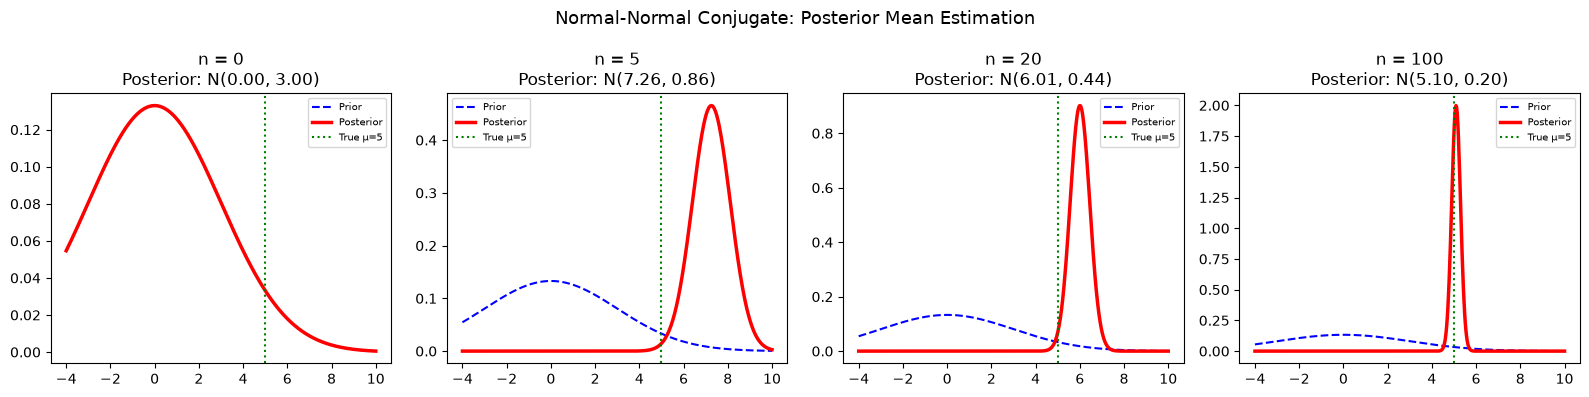

In [3]:
# Normal-Normal conjugate: estimating mean of a Gaussian with Gaussian prior
np.random.seed(0)
true_mu = 5.0
sigma_known = 2.0  # known noise std
n_samples = [0, 5, 20, 100]

mu0, sigma0 = 0.0, 3.0   # prior: N(0, 9)
data = np.random.normal(true_mu, sigma_known, 200)

x_axis = np.linspace(-4, 10, 500)
fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=False)

for ax, n in zip(axes, n_samples):
    # Posterior update formula
    if n == 0:
        mu_n, sigma_n = mu0, sigma0
    else:
        xbar = data[:n].mean()
        sigma_n2 = 1 / (1/sigma0**2 + n/sigma_known**2)
        sigma_n  = np.sqrt(sigma_n2)
        mu_n     = sigma_n2 * (mu0/sigma0**2 + n*xbar/sigma_known**2)
    ax.plot(x_axis, stats.norm.pdf(x_axis, mu0, sigma0), 'b--', lw=1.5, label='Prior')
    ax.plot(x_axis, stats.norm.pdf(x_axis, mu_n, sigma_n), 'r-', lw=2.5, label='Posterior')
    ax.axvline(true_mu, color='g', linestyle=':', label='True μ=5')
    ax.set_title(f'n = {n}\nPosterior: N({mu_n:.2f}, {sigma_n:.2f})')
    ax.legend(fontsize=7)

plt.suptitle('Normal-Normal Conjugate: Posterior Mean Estimation', fontsize=13)
plt.tight_layout(); plt.show()

## 3. Metropolis-Hastings MCMC from Scratch

When the posterior has no closed form, we use **Markov Chain Monte Carlo** to sample from it.

**Metropolis-Hastings algorithm:**
1. Start at $\theta_0$
2. Propose $\theta^* \sim q(\theta^*|\theta_t)$ (e.g. random walk: $\theta^* = \theta_t + \mathcal{N}(0,\sigma^2)$)
3. Compute acceptance ratio: $\alpha = \min\!\left(1,\ \frac{p(\theta^*)\,q(\theta_t|\theta^*)}{p(\theta_t)\,q(\theta^*|\theta_t)}\right)$
4. Accept $\theta^*$ with probability $\alpha$, else stay at $\theta_t$
5. Repeat → chain converges to the target distribution $p(\theta)$

Acceptance rate: 58.01%


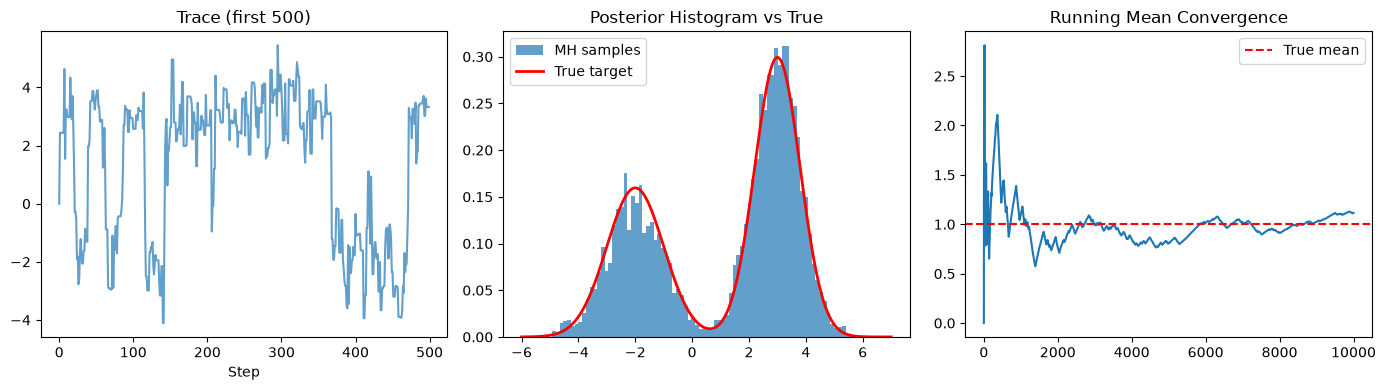

In [4]:
def mh_sampler(log_prob_fn, init, n_samples=5000, proposal_std=0.5):
    """Metropolis-Hastings sampler for a scalar parameter."""
    samples = [init]
    accepted = 0
    current = init
    for _ in range(n_samples - 1):
        proposal = current + np.random.normal(0, proposal_std)
        log_ratio = log_prob_fn(proposal) - log_prob_fn(current)
        if np.log(np.random.rand()) < log_ratio:
            current = proposal
            accepted += 1
        samples.append(current)
    print(f'Acceptance rate: {accepted/(n_samples-1):.2%}')
    return np.array(samples)

# Target: bimodal distribution (mixture of two Gaussians) — no conjugate prior!
def log_target(x):
    return np.log(0.4 * stats.norm.pdf(x, -2, 1) + 0.6 * stats.norm.pdf(x, 3, 0.8) + 1e-300)

np.random.seed(1)
samples = mh_sampler(log_target, init=0.0, n_samples=10000, proposal_std=1.5)
burn_in = 1000
posterior_samples = samples[burn_in:]

x_plot = np.linspace(-6, 7, 500)
true_density = 0.4 * stats.norm.pdf(x_plot, -2, 1) + 0.6 * stats.norm.pdf(x_plot, 3, 0.8)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].plot(samples[:500], alpha=0.7); axes[0].set_title('Trace (first 500)'); axes[0].set_xlabel('Step')
axes[1].hist(posterior_samples, bins=80, density=True, alpha=0.7, label='MH samples')
axes[1].plot(x_plot, true_density, 'r-', lw=2, label='True target')
axes[1].legend(); axes[1].set_title('Posterior Histogram vs True')
axes[2].plot(np.arange(len(samples)), np.cumsum(samples)/(np.arange(len(samples))+1))
axes[2].axhline(0.4*(-2)+0.6*3, color='r', linestyle='--', label='True mean')
axes[2].set_title('Running Mean Convergence'); axes[2].legend()
plt.tight_layout(); plt.show()

## 4. Gaussian Processes from Scratch

A **Gaussian Process** is a distribution over *functions*. Any finite set of function values is jointly Gaussian:

$$f \sim \mathcal{GP}(\mu(x),\; k(x, x'))$$

The **RBF (squared-exponential) kernel**:
$$k(x, x') = \sigma_f^2 \exp\!\left(-\frac{(x-x')^2}{2\ell^2}\right)$$

**GP Regression posterior** (given observations $\mathbf{y}$ at $X$, with noise $\sigma_n^2$):
$$\mu_*(X_*) = K(X_*, X)\,[K(X,X) + \sigma_n^2 I]^{-1}\,\mathbf{y}$$
$$\Sigma_*(X_*) = K(X_*,X_*) - K(X_*,X)\,[K(X,X) + \sigma_n^2 I]^{-1}\,K(X,X_*)$$

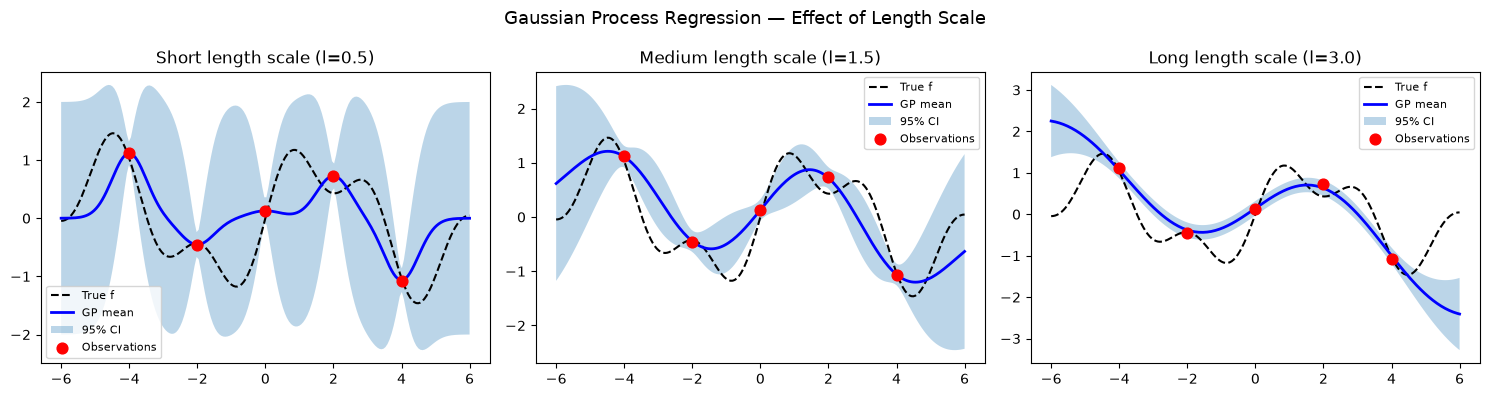

In [5]:
def rbf_kernel(X1, X2, length_scale=1.0, sigma_f=1.0):
    sq_dist = np.sum(X1**2, axis=1).reshape(-1,1) + np.sum(X2**2, axis=1) - 2*X1@X2.T
    return sigma_f**2 * np.exp(-0.5 * sq_dist / length_scale**2)

def gp_posterior(X_train, y_train, X_test, length_scale=1.0, sigma_f=1.0, sigma_n=0.1):
    K    = rbf_kernel(X_train, X_train, length_scale, sigma_f) + sigma_n**2 * np.eye(len(X_train))
    K_s  = rbf_kernel(X_train, X_test, length_scale, sigma_f)
    K_ss = rbf_kernel(X_test, X_test, length_scale, sigma_f)
    L  = np.linalg.cholesky(K)
    Lk = np.linalg.solve(L, K_s)
    mu = Lk.T @ np.linalg.solve(L, y_train)
    sigma = np.sqrt(np.diag(K_ss - Lk.T @ Lk))
    return mu, sigma

# Toy dataset
np.random.seed(42)
f_true = lambda x: np.sin(x) + 0.5*np.sin(2.5*x)
X_train = np.array([[-4],[-2],[0],[2],[4]], dtype=float)
y_train = f_true(X_train.ravel()) + np.random.normal(0, 0.2, len(X_train))
X_test  = np.linspace(-6, 6, 200).reshape(-1, 1)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
configs = [(0.5, 1.0, 'Short length scale (l=0.5)'), (1.5, 1.0, 'Medium length scale (l=1.5)'), (3.0, 1.0, 'Long length scale (l=3.0)')]

for ax, (ls, sf, title) in zip(axes, configs):
    mu, sigma = gp_posterior(X_train, y_train, X_test, ls, sf)
    ax.plot(X_test, f_true(X_test.ravel()), 'k--', lw=1.5, label='True f')
    ax.plot(X_test, mu, 'b-', lw=2, label='GP mean')
    ax.fill_between(X_test.ravel(), mu-2*sigma, mu+2*sigma, alpha=0.3, label='95% CI')
    ax.scatter(X_train, y_train, c='red', zorder=5, s=60, label='Observations')
    ax.set_title(title); ax.legend(fontsize=8)

plt.suptitle('Gaussian Process Regression — Effect of Length Scale', fontsize=13)
plt.tight_layout(); plt.show()

## 5. PyMC: Bayesian Linear Regression

In [6]:
import pymc as pm
import arviz as az
print(f'PyMC version: {pm.__version__}')

# Generate synthetic regression data
np.random.seed(42)
n = 80
X = np.random.uniform(-3, 3, n)
true_alpha, true_beta, true_sigma = 1.5, 2.3, 1.0
y = true_alpha + true_beta * X + np.random.normal(0, true_sigma, n)

with pm.Model() as linear_model:
    # Priors
    alpha = pm.Normal('alpha', mu=0, sigma=5)
    beta  = pm.Normal('beta',  mu=0, sigma=5)
    sigma = pm.HalfNormal('sigma', sigma=2)
    # Likelihood
    mu_obs = alpha + beta * X
    y_obs  = pm.Normal('y_obs', mu=mu_obs, sigma=sigma, observed=y)
    # Sample
    trace = pm.sample(500, tune=500, chains=1, progressbar=False, random_seed=42)

print('\nPosterior summary:')
print(az.summary(trace, var_names=['alpha','beta','sigma'], round_to=3))
print(f'\nTrue values: alpha={true_alpha}, beta={true_beta}, sigma={true_sigma}')

PyMC version: 6.0.1


Initializing NUTS using jitter+adapt_diag...


Sequential sampling (1 chains in 1 job)


NUTS: [alpha, beta, sigma]


Sampling 1 chain for 500 tune and 500 draw iterations (500 + 500 draws total) took 1 seconds.


Only one chain was sampled, this makes it impossible to run some convergence checks



Posterior summary:
        mean     sd  eti89_lb  eti89_ub  ess_bulk  ess_tail  r_hat  mcse_mean  \
alpha  1.507  0.118     1.318     1.689   498.364   330.453    NaN      0.005   
beta   2.375  0.060     2.283     2.469   498.067   235.292    NaN      0.003   
sigma  0.969  0.073     0.867     1.092   566.478   417.417    NaN      0.003   

       mcse_sd  
alpha    0.004  
beta     0.002  
sigma    0.003  

True values: alpha=1.5, beta=2.3, sigma=1.0


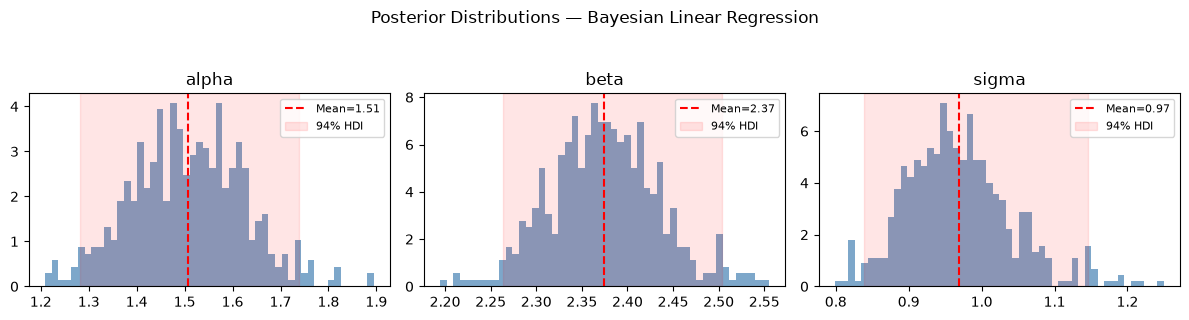

In [7]:
# Plot posterior distributions using matplotlib (arviz 1.2+ API)
fig, axes = plt.subplots(1, 3, figsize=(12, 3))
for ax, var in zip(axes, ['alpha', 'beta', 'sigma']):
    samples_v = trace.posterior[var].values.ravel()
    ax.hist(samples_v, bins=50, density=True, alpha=0.7, color='steelblue')
    ax.axvline(samples_v.mean(), color='r', linestyle='--', label=f'Mean={samples_v.mean():.2f}')
    low, high = np.percentile(samples_v, [2.5, 97.5])
    ax.axvspan(low, high, alpha=0.1, color='red', label='94% HDI')
    ax.set_title(var); ax.legend(fontsize=8)
plt.suptitle('Posterior Distributions — Bayesian Linear Regression', y=1.05)
plt.tight_layout(); plt.show()

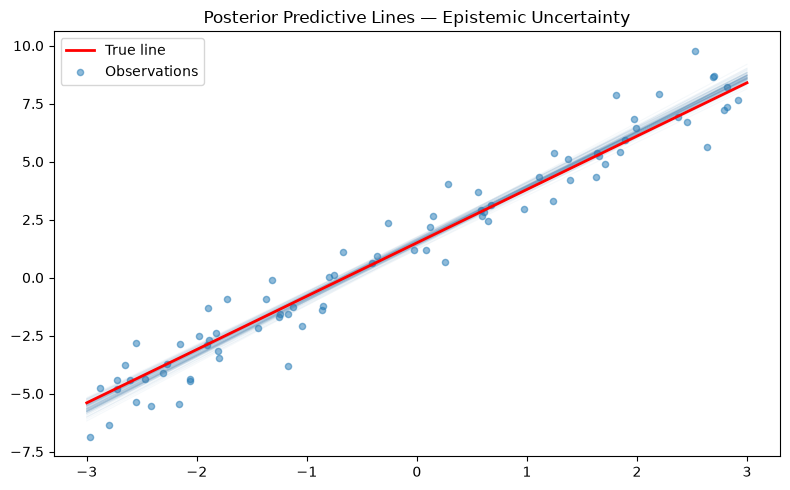

In [8]:
# Plot credible regression lines (uncertainty in the line itself)
x_range = np.linspace(-3, 3, 100)
post_alpha = trace.posterior['alpha'].values.ravel()
post_beta  = trace.posterior['beta'].values.ravel()

fig, ax = plt.subplots(figsize=(8,5))
# Sample 100 posterior lines
idx = np.random.choice(len(post_alpha), 100)
for i in idx:
    ax.plot(x_range, post_alpha[i] + post_beta[i]*x_range, 'steelblue', alpha=0.05, lw=0.8)
ax.plot(x_range, true_alpha + true_beta*x_range, 'r-', lw=2, label='True line')
ax.scatter(X, y, alpha=0.5, s=20, label='Observations')
ax.set_title('Posterior Predictive Lines — Epistemic Uncertainty')
ax.legend(); plt.tight_layout(); plt.show()

## 6. Hierarchical Model — Partial Pooling

When data is grouped (e.g. students per school), we have three options:
- **No pooling**: fit each group independently → overfits small groups
- **Complete pooling**: ignore group membership → underfits large groups
- **Partial pooling** (hierarchical): share information between groups via a hyper-prior

$$\mu_j \sim \mathcal{N}(\mu_{\text{pop}}, \sigma_{\text{pop}})  \quad \text{(group means drawn from population)}$$
$$y_{ij} \sim \mathcal{N}(\mu_j, \sigma)  \quad \text{(observations within each group)}$$

Initializing NUTS using jitter+adapt_diag...


Sequential sampling (1 chains in 1 job)


NUTS: [mu_pop, sigma_pop, mu_store, sigma_obs]


Sampling 1 chain for 500 tune and 500 draw iterations (500 + 500 draws total) took 2 seconds.


Only one chain was sampled, this makes it impossible to run some convergence checks


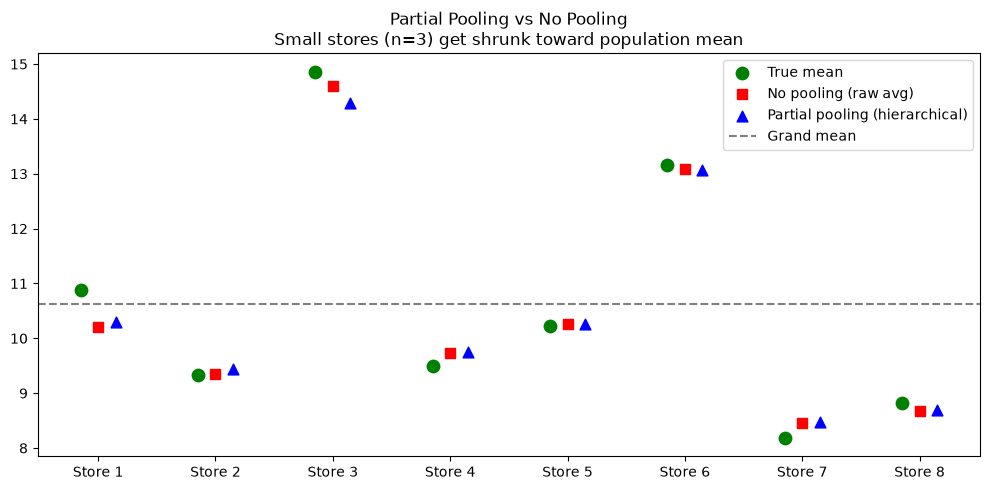

In [9]:
# 8 stores, different numbers of observations, common mean around 10
np.random.seed(5)
n_stores = 8
store_ns  = [3, 3, 5, 30, 30, 50, 50, 50]  # very different sample sizes!
true_means = np.random.normal(10, 2, n_stores)
store_data = [np.random.normal(m, 1.5, n) for m, n in zip(true_means, store_ns)]

store_idx  = np.concatenate([np.full(n, i) for i, n in enumerate(store_ns)])
all_y      = np.concatenate(store_data)

with pm.Model() as hierarchical_model:
    # Hyper-priors
    mu_pop    = pm.Normal('mu_pop', mu=0, sigma=10)
    sigma_pop = pm.HalfNormal('sigma_pop', sigma=5)
    # Group-level means
    mu_store  = pm.Normal('mu_store', mu=mu_pop, sigma=sigma_pop, shape=n_stores)
    sigma_obs = pm.HalfNormal('sigma_obs', sigma=3)
    # Likelihood
    y_obs = pm.Normal('y_obs', mu=mu_store[store_idx], sigma=sigma_obs, observed=all_y)
    trace_h = pm.sample(500, tune=500, chains=1, progressbar=False, random_seed=42)

partial_means = trace_h.posterior['mu_store'].values.mean(axis=(0,1))
no_pool_means = [np.mean(d) for d in store_data]

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(n_stores)
ax.scatter(x - 0.15, true_means,    color='green',  s=80,  zorder=3, label='True mean')
ax.scatter(x,        no_pool_means,  color='red',    s=60,  zorder=3, label='No pooling (raw avg)', marker='s')
ax.scatter(x + 0.15, partial_means,  color='blue',   s=60,  zorder=3, label='Partial pooling (hierarchical)', marker='^')
for i, n in enumerate(store_ns):
    ax.annotate(f'n={n}', (i, min(true_means)-1.5), ha='center', fontsize=8)
ax.axhline(np.mean(true_means), color='gray', linestyle='--', label='Grand mean')
ax.set_xticks(x); ax.set_xticklabels([f'Store {i+1}' for i in x])
ax.set_title('Partial Pooling vs No Pooling\nSmall stores (n=3) get shrunk toward population mean')
ax.legend(); plt.tight_layout(); plt.show()

## 7. Bayesian A/B Testing vs Frequentist p-values

**Frequentist**: compute p-value — probability of seeing data *at least as extreme* if $H_0$ is true. Gives no direct probability that variant B is better.

**Bayesian**: compute $P(p_B > p_A | \text{data})$ — direct, interpretable probability that B wins.

Frequentist chi-square p-value: 0.3816
Significant at 0.05? False

Bayesian P(B > A | data): 0.839 (83.9%)
Expected lift if we choose B: 24.5%
95% Credible interval for (p_B - p_A): [-0.0384, 0.1181]


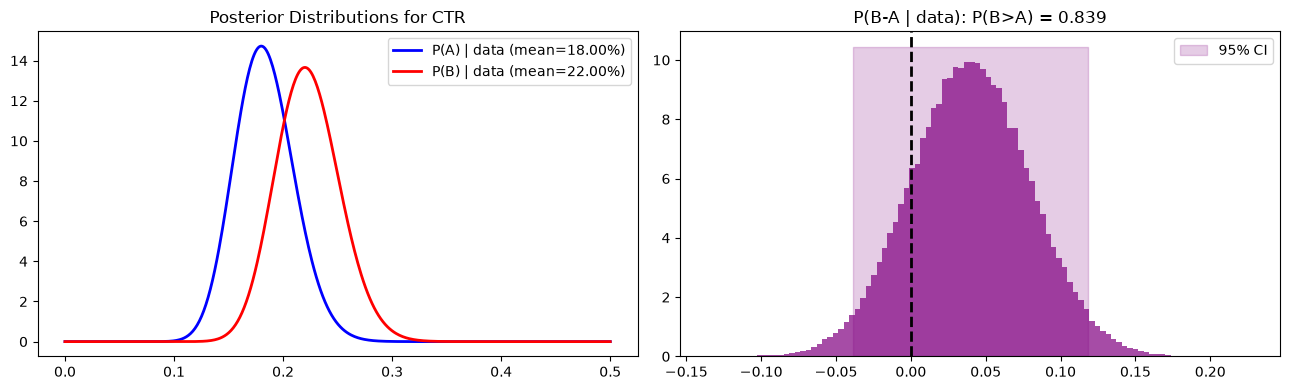

In [10]:
from scipy import stats as sps

# A/B test: email click-through rates
# A: 200 sent, 36 clicked  (18%)
# B: 200 sent, 44 clicked  (22%)
n_A, k_A = 200, 36
n_B, k_B = 200, 44

# --- Frequentist ---
p_A_hat = k_A / n_A
p_B_hat = k_B / n_B
_, p_value = sps.chi2_contingency([[k_A, n_A-k_A],[k_B, n_B-k_B]])[:2]
print(f'Frequentist chi-square p-value: {p_value:.4f}')
print(f'Significant at 0.05? {p_value < 0.05}')

# --- Bayesian ---
# Prior: Beta(1, 1) = uniform = no prior knowledge
# Posterior A: Beta(1 + k_A, 1 + n_A - k_A)
# Posterior B: Beta(1 + k_B, 1 + n_B - k_B)
post_A = sps.beta(1 + k_A, 1 + n_A - k_A)
post_B = sps.beta(1 + k_B, 1 + n_B - k_B)

# Monte Carlo estimate of P(B > A)
mc_samples = 100_000
samples_A = post_A.rvs(mc_samples)
samples_B = post_B.rvs(mc_samples)
prob_B_wins = np.mean(samples_B > samples_A)
expected_lift = np.mean((samples_B - samples_A) / samples_A) * 100

print(f'\nBayesian P(B > A | data): {prob_B_wins:.3f} ({prob_B_wins*100:.1f}%)')
print(f'Expected lift if we choose B: {expected_lift:.1f}%')

# Credible interval for the difference
diff_samples = samples_B - samples_A
ci_low, ci_high = np.percentile(diff_samples, [2.5, 97.5])
print(f'95% Credible interval for (p_B - p_A): [{ci_low:.4f}, {ci_high:.4f}]')

# Visualise posteriors
theta = np.linspace(0, 0.5, 500)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(theta, post_A.pdf(theta), 'b-', lw=2, label=f'P(A) | data (mean={p_A_hat:.2%})')
axes[0].plot(theta, post_B.pdf(theta), 'r-', lw=2, label=f'P(B) | data (mean={p_B_hat:.2%})')
axes[0].set_title('Posterior Distributions for CTR'); axes[0].legend()
axes[1].hist(diff_samples, bins=100, density=True, alpha=0.7, color='purple')
axes[1].axvline(0, color='k', linestyle='--', lw=2)
axes[1].fill_betweenx([0, axes[1].get_ylim()[1] if True else 30],
                       ci_low, ci_high, alpha=0.2, color='purple', label='95% CI')
axes[1].set_title(f'P(B-A | data): P(B>A) = {prob_B_wins:.3f}'); axes[1].legend()
plt.tight_layout(); plt.show()

## Summary

| Concept | Key Equation | Use Case |
|---------|-------------|----------|
| Bayes Theorem | $P(\theta|D) \propto P(D|\theta) P(\theta)$ | Any parameter estimation |
| Beta-Binomial | Posterior = Beta(α+k, β+n-k) | Conversion rates, CTR |
| Normal-Normal | Closed-form posterior mean/variance | Mean estimation |
| Metropolis-Hastings | Accept with prob $\min(1, p^*/p_t)$ | Non-conjugate posteriors |
| GP Regression | $\mu_* = K_{*X}(K_{XX}+\sigma^2 I)^{-1}y$ | Regression with uncertainty |
| Hierarchical | Share info across groups via hyper-prior | Multi-group data |
| Bayesian A/B | $P(B>A|data)$ via Monte Carlo | Direct decision probability |

## Additional Learning Resources

- **[PyMC Documentation](https://www.pymc.io/welcome.html)** — Official tutorials and examples
- **[Statistical Rethinking (McElreath)](https://xcelab.net/rm/statistical-rethinking/)** — The best Bayesian ML textbook, with PyMC code
- **[Bayesian Methods for Hackers](https://github.com/CamDavidsonPilon/Probabilistic-Programming-and-Bayesian-Methods-for-Hackers)** — Free online book, very practical
- **[GP Tutorial — distill.pub](https://distill.pub/2019/visual-exploration-gaussian-processes/)** — Beautiful interactive GP explanation
- **[ArviZ Documentation](https://python.arviz.org/)** — Bayesian analysis visualisation
- **[Gelman et al., Bayesian Data Analysis 3rd Ed.](http://www.stat.columbia.edu/~gelman/book/)** — The academic reference
- **[Thomas Wiecki Blog](https://twiecki.io/)** — PyMC co-creator's practical Bayesian posts